In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Training Recipes Matter

Take the ResNet-50 of that section, change nothing about its architecture, and train it with the methods in use around 2022 instead of those of its 2015 debut. Its ImageNet top-1 accuracy rises from 76.1% to 80.4% [@wightman2021resnet]. That gain, from the *training recipe* alone, exceeds what most new architectures delivered over their predecessors. The "ResNet strikes back" study that produced it trained the unmodified network with three procedures of increasing cost: A3 (100 epochs) reaches 78.1%, A2 (300 epochs) reaches 79.8%, and A1 (600 epochs, the LAMB optimizer, a binary cross-entropy loss, and heavy augmentation) reaches 80.4%.

This has an uncomfortable consequence for reading the literature: a paper from 2016 and a paper from 2022 that both report "ResNet-50" baselines are reporting numbers about four points apart, so accuracy tables that mix eras are not comparable. Some celebrated architecture improvements turned out, on re-examination, to be recipe improvements in disguise. In this section we dissect what changed between 2015 and 2022, implement each ingredient in a few lines, and then run a controlled experiment: the same ResNet-18 trained under both recipes, so you can see the gap with your own eyes rather than take it on faith.

In [1]:
import math
import tensorflow as tf
from d2l import tensorflow as d2l

## What Changed between 2015 and 2022

The original ResNet recipe was already careful: SGD with momentum, weight decay, a learning rate dropped by a factor of 10 twice during training, and random crops and horizontal flips as augmentation [@He.Zhang.Ren.ea.2016]. Between then and roughly 2022, every one of those choices was revisited. The first systematic accounting, in 2019, collected the accumulated tricks (warmup, cosine decay, label smoothing, Mixup, zero-initializing the last batch-norm scale in each block) and showed that stacking them, plus a small tweak to the downsampling path, lifts ResNet-50 from 75.3% to 79.3% [@He.Zhang.Zhang.ea.2019], an early sign that the recipe rivals the architecture. the table summarizes the full shift.

:A 2015 ImageNet recipe and a representative high-accuracy recipe from the
early 2020s. The later column is not a universal standard; strong recipes still
vary by model and compute budget.

| Ingredient | 2015 recipe | 2022 recipe |
|:--|:--|:--|
| Optimizer | SGD with momentum | AdamW or LAMB; tuned SGD remains competitive |
| Schedule | step decay (drop by 10x twice) | cosine decay with linear warmup |
| Augmentation | random crops, horizontal flips | RandAugment, Mixup, CutMix, random erasing |
| Regularization | weight decay | + label smoothing, stochastic depth |
| Duration | 90 epochs | 300 to 600 epochs |
| Evaluated weights | final checkpoint | exponential moving average of weights |

The *optimizer* row shows one common change, from SGD to AdamW
[@Loshchilov.Hutter.2019], rather than a universal replacement. Earlier
Adam implementations folded weight decay into the gradient, where adaptive
rescaling distorts it. AdamW decouples the weight update from the gradient and
made adaptive methods competitive with tuned SGD on many vision recipes. At
batch sizes in the tens of thousands, layerwise rescaling of the update (LARS
[@You.Gitman.Ginsburg.2017] and its Adam-based sibling LAMB, used for
recipe A1 above) can keep training stable.

The *schedule* row replaces discrete drops with a smooth cosine decay [@Loshchilov.Hutter.2016], preceded by a few epochs of linear warmup that protect the network from divergence while its randomly initialized layers produce large, poorly scaled gradients. We implement and plot it below.

The *augmentation* and *regularization* rows are where most of the accuracy lives. RandAugment [@cubuk2020randaugment] applies randomly chosen image transformations at a single tuned strength; Mixup [@zhang2018mixup] and CutMix [@yun2019cutmix] blend pairs of training images and their labels; label smoothing [@Szegedy.Vanhoucke.Ioffe.ea.2016] softens the targets themselves; stochastic depth [@huang2016stochasticdepth] randomly skips whole residual blocks during training. All of these inject noise that the network must average over, and averaging over more noise takes longer: that is why the *duration* row grows from 90 epochs to several hundred. A heavily regularized short run underperforms an unregularized one; regularization and duration must move together.

The final row changes what gets evaluated. Instead of the last iterate of a noisy stochastic optimization, modern recipes evaluate an exponential moving average (EMA) of the weights, a cheap online cousin of the averaging schemes studied by @Izmailov.Podoprikhin.Garipov.ea.2018 . It typically adds a few tenths of a point for one extra copy of the parameters.

None of these ideas is deep in isolation. Their compounded effect, four points of ImageNet top-1 on a fixed network, is what earns them a section of their own.

## Implementing the Ingredients

Each ingredient is a few lines of code. We implement label smoothing, the cosine schedule, Mixup, stochastic depth, and the weight EMA; RandAugment is a library call in practice (its contribution is the *tuning* of augmentation strength, not the code) and we omit it here.

### Label Smoothing

Cross-entropy training with one-hot targets never converges in the logits: the loss keeps decreasing as the correct-class logit grows without bound, so the network is rewarded for unbounded overconfidence. Label smoothing replaces the one-hot target with a mixture that puts weight $1-\epsilon$ on the label and spreads $\epsilon$ uniformly over all $K$ classes. Writing $p_k$ for the predicted softmax probabilities, the loss on an example with label $y$ becomes

$$
\ell_\epsilon = -(1-\epsilon) \log p_y - \frac{\epsilon}{K} \sum_{k=1}^K \log p_k.
$$

The minimizer places probability $1-\epsilon+\epsilon/K$ on the correct class and $\epsilon/K$ on every other class, which requires only a *finite* logit gap. We can see the effect directly: on a prediction that is already extremely confident and correct, the unsmoothed loss is nearly zero, while the smoothed loss is bounded away from zero. The optimizer therefore stops pushing confident examples harder and spends its effort elsewhere.

In [2]:
logits, Y = tf.constant([[10.0, 0.0, 0.0]]), tf.one_hot([0], 3)
for epsilon in (0.0, 0.1):
    loss = tf.keras.losses.CategoricalCrossentropy(
        from_logits=True, label_smoothing=epsilon)(Y, logits)
    print(f'epsilon={epsilon}: loss={float(loss):.4f}')

epsilon=0.0: loss=0.0001
epsilon=0.1: loss=0.6668


### Cosine Schedules with Warmup

A step schedule holds the learning rate constant for tens of epochs and then drops it by a factor of 10, an abrupt change whose timing is two extra hyperparameters. The modern default replaces it with two phases: a linear *warmup* from zero over the first few epochs, then a half-cosine *decay* from the base rate $\eta_0$ to (nearly) zero,

$$
\eta_t = \frac{\eta_0}{2} \left(1 + \cos \frac{\pi (t - t_{\textrm{w}})}{T - t_{\textrm{w}}}\right)
\quad \textrm{for } t \geq t_{\textrm{w}},
$$

where $t_{\textrm{w}}$ is the warmup length and $T$ the total budget. Warmup exists because a freshly initialized network produces large, badly scaled gradients; a few gentle epochs let the running statistics of batch normalization and of the optimizer settle before full-strength updates arrive. The cosine tail matters at the other end: the long stretch of small learning rates is when the noisy iterates settle into a low-loss region, and with Mixup-style augmentation most of the measurable accuracy gain arrives in exactly that tail. Both schedules are one-liners; we plot them for a 45-epoch budget.

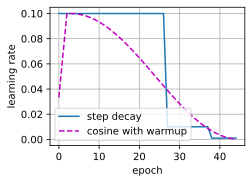

In [3]:
def step_decay(epoch, max_epochs, base_lr):
    """Recipe A: multiply the rate by 0.1 at 60% and 85% of the budget."""
    return base_lr * 0.1 ** sum(epoch >= int(f * max_epochs)
                                for f in (0.6, 0.85))

def cosine_warmup(epoch, max_epochs, base_lr, warmup=3):
    """Recipe B: linear warmup, then a half-cosine decay to zero."""
    if epoch < warmup:
        return base_lr * (epoch + 1) / warmup
    t = (epoch - warmup) / (max_epochs - warmup)
    return base_lr * 0.5 * (1 + math.cos(math.pi * t))

epochs = list(range(45))
d2l.plot(epochs, [[step_decay(e, 45, 0.1) for e in epochs],
                  [cosine_warmup(e, 45, 0.1) for e in epochs]],
         xlabel='epoch', ylabel='learning rate',
         legend=['step decay', 'cosine with warmup'])

### Mixup

Mixup [@zhang2018mixup] builds each training example as a convex combination of two real ones. Draw a mixing weight $\lambda \sim \mathrm{Beta}(\alpha, \alpha)$ and a random partner for every image in the batch, then train on

$$
\tilde{\mathbf{x}} = \lambda \mathbf{x}_i + (1-\lambda) \mathbf{x}_j, \qquad
\tilde{y} = \lambda y_i + (1-\lambda) y_j,
$$

where the mixed label $\tilde{y}$ is a distribution over classes. Because cross-entropy is linear in the target distribution, training on $\tilde{y}$ is the same as taking a $\lambda$-weighted combination of the two ordinary losses, which is how we implement it: no soft-label plumbing needed. The effect is a strong regularizer: the network is asked to behave *linearly between* training points, which flattens its decision boundaries and combats the memorization of individual examples. With the usual small $\alpha$ (around 0.1 to 0.2) the Beta distribution is bathtub-shaped, so most batches are barely mixed and a few are blended heavily.

The implementation is a handful of array operations on the batch, with a single $\lambda$ shared across it:

In [4]:
def mixup(X, y, alpha):
    """Return a mixed batch, both label sets, and the mixing weight."""
    g1, g2 = tf.random.gamma([], alpha), tf.random.gamma([], alpha)
    lam = float(g1 / (g1 + g2))  # Beta(a, a) as a ratio of Gammas
    perm = tf.random.shuffle(tf.range(tf.shape(X)[0]))
    return (lam * X + (1 - lam) * tf.gather(X, perm),
            y, tf.gather(y, perm), lam)

To make the blending visible we mix a batch of Fashion-MNIST images with $\alpha = 2$, which concentrates $\lambda$ near $0.5$ (training uses a much smaller $\alpha$). The top row shows the originals, the bottom row their mixtures with a shuffled partner:

lambda = 0.14


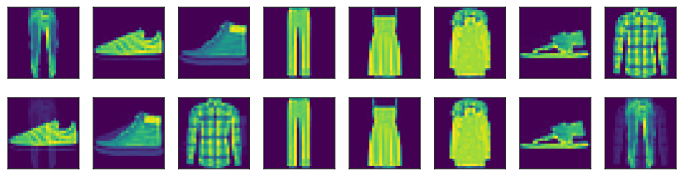

In [5]:
data = d2l.FashionMNIST(batch_size=8)
X, y = next(iter(data.train_dataloader()))
X_mix, y_a, y_b, lam = mixup(X, y, alpha=2.0)
d2l.show_images(tf.squeeze(tf.concat([X, X_mix], axis=0), -1), 2, 8)
print(f'lambda = {lam:.2f}')

CutMix [@yun2019cutmix] is the spatial sibling: instead of blending two images everywhere, it cuts a rectangular patch from one image and pastes it into the other, mixing the labels in proportion to the patch area. It preserves local image statistics (every pixel comes from a real photograph) and in practice modern recipes alternate randomly between Mixup and CutMix from batch to batch. Its implementation is a rectangle-slicing variant of the code above, which we leave as an exercise.

### Stochastic Depth

Dropout (that section) randomly silences individual activations. Stochastic depth [@huang2016stochasticdepth] applies the same idea at the coarsest possible granularity: during training, each residual block's *entire* branch is dropped with some probability, so the block passes its input through unchanged and that training step sees a shallower network. Residual connections make this safe, since the identity path is always there to carry the signal. For a residual block computing $\mathbf{x} + f(\mathbf{x})$, we replace the branch by

$$
\mathbf{x} + \frac{b}{1 - p} f(\mathbf{x}), \qquad b \sim \mathrm{Bernoulli}(1-p),
$$

where the $1/(1-p)$ rescaling keeps the branch's expected contribution unchanged, so at evaluation time we simply use the block as-is. Modern implementations draw $b$ per *sample* rather than per batch. The wrapper below subclasses the `Residual` block of that section and inserts the drop before the addition; running a large batch through it in training mode confirms that close to a fraction $p$ of the samples pass through untouched.

In [6]:
def drop_path(Y, p, training):
    if not training or p == 0:
        return Y
    keep = tf.cast(tf.random.uniform((tf.shape(Y)[0], 1, 1, 1)) > p, Y.dtype)
    return Y * keep / (1 - p)

class StochasticResidual(d2l.Residual):
    """A residual block whose branch is dropped with probability p."""
    def __init__(self, num_channels, p):
        super().__init__(num_channels)
        self.p = p

    def call(self, X, training=False):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X),
                                               training=training))
        Y = self.bn2(self.conv2(Y), training=training)
        return tf.keras.activations.relu(drop_path(Y, self.p, training) + X)

blk, X = StochasticResidual(3, p=0.5), tf.random.normal((1000, 8, 8, 3))
Y = blk(X, training=True)
diff = tf.reshape(tf.abs(Y - tf.keras.activations.relu(X)), (1000, -1))
dropped = tf.reduce_mean(tf.cast(tf.reduce_max(diff, 1) == 0, tf.float32))
print(f'fraction of samples with a dropped branch: {float(dropped):.3f}')

fraction of samples with a dropped branch: 0.523


In deep networks the drop probability is usually ramped linearly from 0 in the
earliest block to a maximum (0.1 to 0.5) in the last. The vectorized
per-sample implementation above computes the branch before masking it, so it
regularizes but does not save arithmetic. The original per-minibatch method can
skip a dropped branch entirely and thereby shorten training.

### Averaging Weights

The last row of the table costs almost nothing. Stochastic gradients keep the parameters jittering around a good region of the loss surface rather than settling at a point; averaging the iterates cancels much of that jitter and lands closer to the region's center, a phenomenon exploited more aggressively by stochastic weight averaging [@Izmailov.Podoprikhin.Garipov.ea.2018]. The online version keeps a *shadow copy* $\bar{\theta}$ of the parameters and after every update blends in the current weights,

$$
\bar{\theta} \leftarrow \beta \bar{\theta} + (1-\beta) \theta,
$$

with a decay $\beta$ close to 1 (0.99 to 0.9999). Training uses $\theta$ as usual; only evaluation uses $\bar{\theta}$. The class below is the entire mechanism; we exercise it on a deliberately noisy sequence of "weights" to show the variance reduction.

Keras builds this into the optimizer:
`tf.keras.optimizers.AdamW(..., use_ema=True, ema_momentum=0.99)` maintains the
shadow weights internally. Its `finalize_variable_values` method copies the
averages into the model variables before evaluation when a custom loop does
not finalize them automatically.

The choice of $\beta$ sets an averaging horizon of roughly $1/(1-\beta)$ steps. If that horizon is long relative to the schedule's tail, the average lags behind the still-improving weights and EMA *hurts*; matched to the tail, it helps. The exercises ask you to map this trade-off.

## One Network, Two Recipes

Now we put the ingredients together. The network is the ResNet-18 of
that section, rebuilt here from the library's `Residual` block. The
task is Fashion-MNIST at $96 \times 96$ resolution, with one deliberate
modification: we train on a random subset of 10,000 of the 60,000 training
images. This makes regularization consequential without turning the notebook
into an ImageNet-scale experiment. You can rerun it at full size by changing
one argument, but the comparison would then require retuning both recipes.

The executable comparison uses a compact subset of the full recipe: optimizer,
schedule, label smoothing, Mixup, and duration. It omits RandAugment, CutMix,
stochastic depth, and EMA so that the experiment remains small enough to rerun
in a textbook notebook. We call it the *compact modern recipe* below rather
than attributing its result to the entire package.

We give the modern recipe a 1.5x longer budget (45 epochs versus 30), since longer training is itself part of the recipe, and evaluate both on the untouched 10,000-image test set.

This reduced path demonstrates the optimizer and schedule rather than repeating
the full head-to-head run. Keras schedules are objects passed as the learning
rate, and the optimizer maintains the weight EMA itself. With 79 batches per
epoch, 3 warmup epochs, and a 45-epoch budget:

In [7]:
schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0, decay_steps=42 * 79,
    warmup_target=2e-3, warmup_steps=3 * 79)
optimizer = tf.keras.optimizers.AdamW(learning_rate=schedule,
                                      weight_decay=0.05,
                                      use_ema=True, ema_momentum=0.99)
[round(float(schedule(step)), 6) for step in (0, 3 * 79, 24 * 79, 45 * 79)]

[0.0, 0.002, 0.001, 0.0]

the table reports one seeded run per implementation,
rounded to the half point — about the level at which these numbers
reproduce from run to run. In both implementations the compact modern
recipe gains roughly half a point on the subsampled task; the gain is
consistent in direction but modest in size at this scale, and this small
teaching experiment is not a substitute for the many-seed ImageNet
evaluation of @wightman2021resnet.

:The same ResNet-18 under both recipes (10,000 Fashion-MNIST training images at
$96 \times 96$; test accuracy, one seeded run each, rounded).

| Implementation | Recipe A (2015, 30 epochs) | Compact modern recipe (45 epochs) |
|:--|:--|:--|
| PyTorch | ≈90.5% | ≈91% |
| JAX | ≈90.5% | ≈91% |

Two practical warnings from this experiment. First, the recipes' hyperparameters are not interchangeable: recipe A's learning rate of 0.05 would make AdamW diverge, and recipe B's rate of 0.002 would starve SGD, so ablating one ingredient requires retuning around it (this is why credible recipe ablations, like those of @wightman2021resnet, are expensive). Second, the modern recipe's *training* loss stays well above recipe A's, because Mixup and label smoothing make the training targets themselves harder; comparing training losses across recipes tells you nothing about which generalizes better.

## Reading the Scoreboard

The recipe story reshapes how you should read reported benchmark numbers, on ImageNet above all.

First, ImageNet top-1 accuracy separates strong models less clearly than it
once did, and the residual differences are heavily *recipe-confounded*. When
an architecture paper reports beating a baseline by a point, the first
question is whether both were trained with comparable recipes; as we saw, the
recipe alone can change accuracy by four points on a fixed network. Careful
papers now
retrain baselines under their own recipe. Older cross-paper tables do not
support precise conclusions from one-point gaps.

Second, held-out numbers age for more than one reason. When
@Recht.Roelofs.Schmidt.ea.2019 collected ImageNet-V2 by following the
original data-collection protocol [@Deng.Dong.Socher.ea.2009], models lost
11--14 points. The authors found that gains on the original validation set
still transferred and attributed the level shift to a slightly harder image
distribution rather than adaptive overfitting. A separate problem concerns
the labels on the *original* validation set. @beyer2020imagenetreal
collected multi-label ReaL annotations and showed that many apparent errors
involve ambiguous or multi-object images. ReaL does not relabel ImageNet-V2,
so it does not explain away the distribution shift. Together the studies say
that both test distribution and annotation protocol matter once model
accuracies are close.

Third, the discriminating evaluations have moved downstream. Because classification at ImageNet scale is nearly solved, backbones are now separated by how well their features *transfer*: object detection on COCO and semantic segmentation on ADE20K stress resolution, receptive field, and memory behavior in ways a 224-pixel classification task does not, and they reorder models that are indistinguishable on top-1 accuracy. When we evaluate the architectures of the following sections, transfer performance is the score that modern papers argue over.

## Summary and Discussion

Between 2015 and the early 2020s, high-accuracy convolutional recipes changed
along several axes: many adopted AdamW or LAMB, cosine decay with warmup,
stronger augmentation, label smoothing, stochastic depth, longer budgets, and
EMA evaluation. These choices are a menu rather than a single standard. In
the cited ResNet-50 study their combined effect is about four ImageNet points.
Our smaller experiment tests a compact subset of that menu on subsampled
Fashion-MNIST and reports its seed-to-seed variation.

That number carries two lessons beyond the ingredients themselves. Methodologically, no architecture comparison is meaningful unless the recipes match; the strong baseline, retrained with modern methods, is the control experiment of this field. And practically, if you have a fixed network and a fixed budget, tuning the recipe is usually the cheapest accuracy available. that section turns this logic around: starting from the modern recipe, it asks how much of the transformer's advantage over convnets survives once the recipe is equalized, and modernizes the architecture itself.

## Exercises

1. Ablate the modern recipe one ingredient at a time on `FashionMNIST10k`: (i) remove Mixup, (ii) remove label smoothing, (iii) replace the cosine schedule by a constant rate after warmup, (iv) replace AdamW by SGD with momentum (retune the learning rate!). Which single ingredient contributes the most? Do the contributions add up to the total gap?
1. Disentangle the optimizer from the schedule: train recipe A's SGD-with-momentum under recipe B's cosine-with-warmup schedule, and AdamW under recipe A's step schedule. How much of the gap in the table is the schedule rather than the optimizer?
1. @wightman2021resnet train with a *binary* cross-entropy loss, treating each class as an independent yes/no target. Why does this pair naturally with Mixup and CutMix? Consider what the "correct" target should be for an image that genuinely contains parts of two classes, and contrast how softmax and sigmoid outputs represent it.
1. Add the `EMA` class to the modern recipe (update after every optimizer step, evaluate the shadow weights) and sweep the decay over 0.9, 0.99, and 0.999. Relate the best decay to the number of optimizer steps in the schedule's low-learning-rate tail, using the horizon estimate of roughly $1/(1-\beta)$ steps.
1. Implement CutMix following the equation: sample a rectangle whose area fraction is $1-\lambda$, paste that region from the shuffled batch, and mix the labels by actual area. Compare against Mixup on `FashionMNIST10k`, then alternate the two.